In [4]:
from pathlib import Path
import zipfile

import numpy as np
import pandas as pd


def parse_header(line):
    """Parse one IGRA header line."""

    return {

        "station": line[1:12].strip(),

        "year": int(line[13:17]),
        "month": int(line[18:20]),
        "day": int(line[21:23]),
        "hour": int(line[24:26]),

        "release_time": int(line[27:31]),

        "numlev": int(line[32:36]),

        "p_src": line[37:45].strip(),
        "np_src": line[46:54].strip(),

        "lat": int(line[55:62]) / 10000,
        "lon": int(line[63:71]) / 10000,
    }


def parse_level(line):
    """Parse one IGRA profile line."""

    return {

        "lvltyp1": int(line[0]),
        "lvltyp2": int(line[1]),

        "etime": int(line[3:8]),

        "pressure": int(line[9:15]),

        "pflag": line[15],

        "height": int(line[16:21]),

        "zflag": line[21],

        "temperature": int(line[22:27]),

        "tflag": line[27],

        "rh": int(line[28:33]),

        "dpdp": int(line[34:39]),

        "wind_dir": int(line[40:45]),

        "wind_speed": int(line[46:51]),

    }


# Parse the entire file.
def parse_soundings(lines: list[str]) -> dict[pd.Timestamp, pd.DataFrame]:
    """
    Parse an IGRA station file into a dictionary of soundings.

    Parameters
    ----------
    lines : list[str]
        List of lines from an IGRA station file.

    Returns
    -------
    dict[pandas.Timestamp, pandas.DataFrame]
        Dictionary whose keys are launch datetimes and whose values are
        DataFrames containing the sounding profile. The header metadata
        are stored in each DataFrame's ``attrs`` dictionary.
    """

    soundings = {}

    i = 0

    while i < len(lines):

        if not lines[i].startswith("#"):
            i += 1
            continue

        header = parse_header(lines[i])

        profile = []

        for j in range(header["numlev"]):

            profile.append(parse_level(lines[i + j + 1]))

        df = pd.DataFrame(profile)

        # Replace IGRA missing values with NaN
        df.replace([-9999, -8888], np.nan, inplace=True)

        # Convert units
        df["pressure"] /= 100.0          # Pa -> hPa
        df["temperature"] /= 10.0        # tenths C -> C
        df["dpdp"] /= 10.0               # tenths C -> C
        df["dewpoint"] = df["temperature"] - df["dpdp"]
        df["wind_speed"] /= 10.0         # tenths m/s -> m/s

        # Datetime for this sounding.
        dt = pd.Timestamp(
            year=header["year"],
            month=header["month"],
            day=header["day"],
            hour=header["hour"],
        )

        # Store metadata in DataFrame attributes
        df.attrs = header

        # Save sounding
        soundings[dt] = df

        i += header["numlev"] + 1

    return soundings


zip_path = Path("BBM00078954-data.txt.zip")


with zipfile.ZipFile(zip_path, mode='r') as z:

    text_files = [file for file in z.namelist() if file.endswith(".txt")]

    if not text_files:
        raise("No .txt files found in ZIP")

    with z.open(text_files[0]) as f:
        lines = f.read().decode("ascii").splitlines()

soundings = parse_soundings(lines)

In [5]:
profile = soundings[pd.Timestamp("2026-07-04 12:00")]
profile

,lvltyp1,lvltyp2,etime,pressure,pflag,height,zflag,temperature,tflag,rh,dpdp,wind_dir,wind_speed
0,2,1,NaN,1010.0,B,NaN,,27.4,B,NaN,4.2,80.0,9.3
1,2,0,NaN,1004.0,,NaN,,27.0,B,NaN,4.8,NaN,NaN
2,1,0,NaN,1000.0,,142.0,B,26.6,B,NaN,5.0,70.0,12.3
3,2,0,NaN,994.0,,NaN,,NaN,,NaN,NaN,70.0,12.3
4,2,0,NaN,982.0,,NaN,,NaN,,NaN,NaN,70.0,12.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...
174,3,0,NaN,NaN,,27000.0,,NaN,,NaN,NaN,85.0,15.9
175,3,0,NaN,NaN,,27300.0,,NaN,,NaN,NaN,95.0,20.1
176,3,0,NaN,NaN,,27900.0,,NaN,,NaN,NaN,120.0,12.3
177,3,0,NaN,NaN,,28500.0,,NaN,,NaN,NaN,85.0,12.3


In [26]:
from pathlib import Path
import zipfile

import numpy as np
import pandas as pd
import xarray as xr


DATA_DIR = Path("data")
filename = "BBM00078954-data.txt.zip"
zip_path = Path.cwd().parents[1] / DATA_DIR / filename


with zipfile.ZipFile(zip_path, mode='r') as zip_file:

    text_files = [file for file in zip_file.namelist() if file.endswith(".txt")]

    if not text_files:
        raise(f"No .txt files found in {zip_path.resolve().name}.")

    with zip_file.open(text_files[0]) as f:
        lines = f.read().decode("ascii").splitlines()


lines

['#BBM00078954 1965 07 30 12 9999   23 ncdc6301           130716  -594922',
 '21 -9999 100900B   56   272B  870 -9999   100    50 ',
 '10 -9999 100000   140B  265B  860 -9999   100    50 ',
 '20 -9999  95400   530B  228B  840 -9999 -9999 -9999 ',
 '10 -9999  85000  1554B  178B  680 -9999   110   170 ',
 '20 -9999  73400  2800B  113B  560 -9999 -9999 -9999 ',
 '10 -9999  70000  3194B   84B  570 -9999   125   140 ',
 '20 -9999  60700  4370B   -2B  770 -9999 -9999 -9999 ',
 '10 -9999  50000  5889B  -76B  630 -9999   100   150 ',
 '20 -9999  41300  7370B -153B  150 -9999 -9999 -9999 ',
 '10 -9999  40000  7600B -171B  170 -9999   105   150 ',
 '20 -9999  32800  9030B -282B  450 -9999 -9999 -9999 ',
 '10 -9999  30000  9689B -330B  320 -9999    75   100 ',
 '10 -9999  25000 10941B -430B-9999 -9999    64    80 ',
 '10 -9999  20000 12401B -560B-9999 -9999    40    50 ',
 '20 -9999  15700 13900B -683B-9999 -9999 -9999 -9999 ',
 '20 -9999  15500 13990B -658B-9999 -9999 -9999 -9999 ',
 '10 -9999  

In [46]:
from pathlib import Path
import zipfile

import numpy as np
import pandas as pd
import xarray as xr


def _parse_header(line: list) -> dict:
    """Parse one IGRA header line using the Header Record Format from
    https://www.ncei.noaa.gov/data/integrated-global-radiosonde-archive/doc/igra2-data-format.txt."""

    return {

        "station": line[1:12].strip(),

        "year": int(line[13:17]),
        "month": int(line[18:20]),
        "day": int(line[21:23]),
        "hour": int(line[24:26]),

        "release_time": int(line[27:31]),

        "numlev": int(line[32:36]),

        "p_src": line[37:45].strip(),
        "np_src": line[46:54].strip(),

        "lat": int(line[55:62]) / 10000,
        "lon": int(line[63:71]) / 10000,

    }


def _parse_level(line: list) -> dict:
    """Parse one IGRA profile line using the Header Record Format from
    https://www.ncei.noaa.gov/data/integrated-global-radiosonde-archive/doc/igra2-data-format.txt."""

    return {

        "lvltyp1": int(line[0]),
        "lvltyp2": int(line[1]),

        "etime": int(line[3:8]),

        "pressure": int(line[9:15]),

        "pflag": line[15],

        "height": int(line[16:21]),

        "zflag": line[21],

        "temperature": int(line[22:27]),

        "tflag": line[27],

        "rh": int(line[28:33]),

        "dpdp": int(line[34:39]),

        "wind_dir": int(line[40:45]),

        "wind_speed": int(line[46:51]),

    }


# Parse the entire file.
def parse_soundings(lines: list[str]) -> dict[pd.Timestamp, pd.DataFrame]:
    """
    Parse an IGRA station file into a dictionary of soundings.

    Parameters
    ----------
    lines : list[str]
        List of lines from an IGRA station file.

    Returns
    -------
    dict[pandas.Timestamp, pandas.DataFrame]
        Dictionary whose keys are launch datetimes and whose values are
        DataFrames containing the sounding profile. The header metadata
        are stored in each DataFrame's ``attrs`` dictionary.
    """

    soundings = {}

    line_number = 0

    # Loop through each profile associated with each heading.
    while line_number < len(lines):

        # Skip if line is not a header.
        if not lines[line_number].startswith("#"):
            line_number += 1
            continue

        header = _parse_header(lines[line_number])

        profile = []

        for sounding_level in range(header["numlev"]):

            profile.append(_parse_level(lines[line_number + sounding_level + 1]))

        df = pd.DataFrame(profile)

        # Replace IGRA missing values with NaN.
        df.replace([-9999, -8888], np.nan, inplace=True)

        # Convert units
        df["pressure"] /= 100.0          # Pa -> hPa
        df["temperature"] /= 10.0        # tenths C -> C
        df["dpdp"] /= 10.0               # tenths C -> C
        df["dewpoint"] = df["temperature"] - df["dpdp"]
        df["wind_speed"] /= 10.0         # tenths m/s -> m/s

        # Datetime for this sounding.
        dt = pd.Timestamp(
            year=header["year"],
            month=header["month"],
            day=header["day"],
            hour=header["hour"],
        )

        # Store metadata in DataFrame attributes
        df.attrs = header

        # Save sounding
        soundings[dt] = df

        line_number += header["numlev"] + 1

    return soundings


def soundings_to_xarray(soundings):
    """
    Convert a dictionary of IGRA soundings into an xarray Dataset.

    Parameters
    ----------
    soundings : dict[pd.Timestamp, pd.DataFrame]

    Returns
    -------
    xr.Dataset
    """

    # Sort chronologically
    times = sorted(soundings.keys())

    ntime = len(times)
    max_levels = max(len(soundings[t]) for t in times)

    profile_vars = [
        "pressure",
        "height",
        "temperature",
        "dewpoint",
        "dew_point_depression",
        "wind_dir",
        "wind_speed",
        "relative_humidity",
        "lvltyp1",
        "lvltyp2",
        "etime",
    ]

    # Allocate arrays
    arrays = {
        var: np.full((ntime, max_levels), np.nan)
        for var in profile_vars
    }

    # Metadata (one value per sounding)
    release_time = np.full(ntime, np.nan)
    numlev = np.full(ntime, np.nan)

    p_src = []
    np_src = []

    lat = np.full(ntime, np.nan)
    lon = np.full(ntime, np.nan)

    # Fill arrays
    for i, time in enumerate(times):

        df = soundings[time]

        n = len(df)

        for var in profile_vars:

            if var in df.columns:
                arrays[var][i, :n] = df[var].values

        attrs = df.attrs

        release_time[i] = attrs["release_time"]
        numlev[i] = attrs["numlev"]

        lat[i] = attrs["lat"]
        lon[i] = attrs["lon"]

        p_src.append(attrs["p_src"])
        np_src.append(attrs["np_src"])

    ds = xr.Dataset(

        data_vars={

            **{
                var: (("time", "level"), arrays[var])
                for var in profile_vars
            },

            "release_time": ("time", release_time),
            "numlev": ("time", numlev),

            "latitude": ("time", lat),
            "longitude": ("time", lon),

            "pressure_source": ("time", np.asarray(p_src, dtype="U16")),
            "nonpressure_source": ("time", np.asarray(np_src, dtype="U16")),
        },

        coords={

            "time": pd.to_datetime(times),

            "level": np.arange(max_levels),
        },

        attrs={
            "source": "NOAA NCEI Integrated Global Radiosonde Archive (IGRA Version 2)",
            "institution": "NOAA National Centers for Environmental Information",
            "station": soundings[times[0]].attrs["station"],
            "title": "IGRA Radiosonde Profiles",
            "history": (
                f"Converted from IGRA text format on "
                f"{pd.Timestamp.now().strftime('%Y-%m-%d %H:%M UTC')}"
            ),
            "references": (
                "https://www.ncei.noaa.gov/products/weather-balloon/integrated-global-radiosonde-archive"
                "integrated-global-radiosonde-archive"
            ),
            "featureType": "timeSeriesProfile"
        }

    )

    return ds


DATA_DIR = Path("data")
filename = "BBM00078954-data.txt.zip"
zip_path = Path.cwd().parents[1] / DATA_DIR
zip_file = zip_path / filename


with zipfile.ZipFile(zip_path, mode='r') as zip_file:

    text_files = [file for file in zip_file.namelist() if file.endswith(".txt")]

    if not text_files:
        raise(f"No .txt files found in {zip_path.resolve().name}.")

    with zip_file.open(text_files[0]) as f:
        lines = f.read().decode("ascii").splitlines()

soundings = parse_soundings(lines)

ds = soundings_to_xarray(soundings)
print(ds)

ds.to_netcdf(filename.split('-')[0] + '.nc')

<xarray.Dataset> Size: 659MB
Dimensions:               (time: 32308, level: 230)
Coordinates:
  * time                  (time) datetime64[ns] 258kB 1965-07-30T12:00:00 ......
  * level                 (level) int64 2kB 0 1 2 3 4 5 ... 225 226 227 228 229
Data variables: (12/17)
    pressure              (time, level) float64 59MB 1.009e+03 1e+03 ... nan nan
    height                (time, level) float64 59MB 56.0 140.0 ... nan nan
    temperature           (time, level) float64 59MB 27.2 26.5 22.8 ... nan nan
    dewpoint              (time, level) float64 59MB nan nan nan ... nan nan nan
    dew_point_depression  (time, level) float64 59MB nan nan nan ... nan nan nan
    wind_dir              (time, level) float64 59MB 100.0 100.0 nan ... nan nan
    ...                    ...
    release_time          (time) float64 258kB 9.999e+03 9.999e+03 ... 1.102e+03
    numlev                (time) float64 258kB 23.0 23.0 23.0 ... 166.0 179.0
    latitude              (time) float64 258kB 13.0

<xarray.Dataset> Size: 659MB
Dimensions:               (time: 32308, level: 230)
Coordinates:
  * time                  (time) datetime64[ns] 258kB 1965-07-30T12:00:00 ......
  * level                 (level) int64 2kB 0 1 2 3 4 5 ... 225 226 227 228 229
Data variables: (12/17)
    pressure              (time, level) float64 59MB 1.009e+03 1e+03 ... nan nan
    height                (time, level) float64 59MB 56.0 140.0 ... nan nan
    temperature           (time, level) float64 59MB 27.2 26.5 22.8 ... nan nan
    dewpoint              (time, level) float64 59MB nan nan nan ... nan nan nan
    dew_point_depression  (time, level) float64 59MB nan nan nan ... nan nan nan
    wind_dir              (time, level) float64 59MB 100.0 100.0 nan ... nan nan
    ...                    ...
    release_time          (time) float64 258kB 9.999e+03 9.999e+03 ... 1.102e+03
    numlev                (time) float64 258kB 23.0 23.0 23.0 ... 166.0 179.0
    latitude              (time) float64 258kB 13.07 13.07 13.07 ... 13.07 13.07
    longitude             (time) float64 258kB -59.49 -59.49 ... -59.49 -59.49
    pressure_source       (time) <U16 2MB 'ncdc6301' 'ncdc6301' ... 'ncdc-gts'
    nonpressure_source    (time) <U16 2MB '' '' '' ... 'ncdc-gts' 'ncdc-gts'
Attributes:
    source:       NOAA NCEI Integrated Global Radiosonde Archive (IGRA Versio...
    institution:  NOAA National Centers for Environmental Information
    station:      BBM00078954
    title:        IGRA Radiosonde Profiles
    history:      Converted from IGRA text format on 2026-07-27 14:21 UTC
    references:   https://www.ncei.noaa.gov/products/weather-balloon/integrat...
    featureType:  timeSeriesProfile

In [57]:
DATA_DIR = Path("data")
filename = "BBM00078954-data.txt.zip"
zip_path = Path.cwd().parents[1] / DATA_DIR
zip_file = zip_path / filename

In [58]:
zip_file

WindowsPath('C:/Users/cpope/Documents/Python/sif/data/BBM00078954-data.txt.zip')

In [50]:
h = parse_soundings(lines)

In [51]:
type(h)

dict

In [54]:
len(h.keys())

32308

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from metpy.plots import SkewT
import xarray as xr

from config import DATA_DIR


filename = "BBM00078954.nc"
data = Path.cwd().parents[1] / DATA_DIR / filename


# Load DataFrame
ds = xr.open_dataset(data)

ds

<xarray.Dataset> Size: 657MB
Dimensions:               (time: 32308, level: 230)
Coordinates:
  * time                  (time) datetime64[ns] 258kB 1965-07-30T12:00:00 ......
  * level                 (level) int64 2kB 0 1 2 3 4 5 ... 225 226 227 228 229
Data variables: (12/17)
    pressure              (time, level) float64 59MB ...
    height                (time, level) float64 59MB ...
    temperature           (time, level) float64 59MB ...
    dewpoint              (time, level) float64 59MB ...
    dew_point_depression  (time, level) float64 59MB ...
    wind_dir              (time, level) float64 59MB ...
    ...                    ...
    release_time          (time) float64 258kB ...
    numlev                (time) float64 258kB ...
    latitude              (time) float64 258kB ...
    longitude             (time) float64 258kB ...
    pressure_source       (time) <U8 1MB ...
    nonpressure_source    (time) <U8 1MB ...
Attributes:
    source:       NOAA NCEI Integrated Global Radiosonde Archive (IGRA Versio...
    institution:  NOAA National Centers for Environmental Information
    station:      BBM00078954
    title:        IGRA Radiosonde Profiles
    history:      Converted from IGRA text format on 2026-07-27 17:17 UTC
    references:   https://www.ncei.noaa.gov/products/weather-balloon/integrat...
    featureType:  timeSeriesProfile

In [17]:
recent = ds.sel(time='2026-04-04T12:00:00.000000000')

pressure = recent['pressure'].values / 100
temperature = recent['temperature'].values - 273.15
dewpoint = recent['dewpoint'].values - 273.15

# Remove NaN.
mask = (
    ~np.isnan(pressure) &
    ~np.isnan(temperature) &
    ~np.isnan(dewpoint)
)

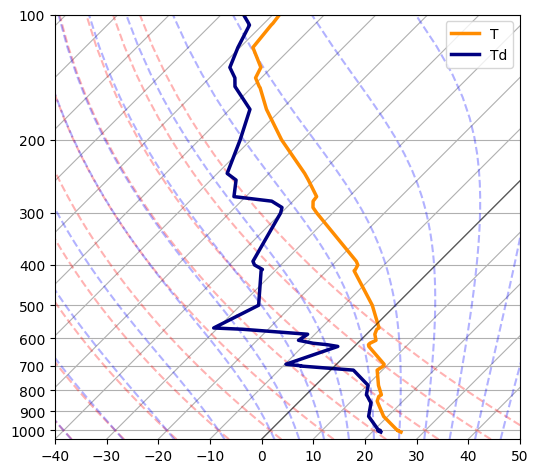

In [18]:
fig = plt.figure(figsize=(6, 8))
skew = SkewT(fig, rotation=45)

skew.plot(pressure[mask], temperature[mask], color='darkorange', linewidth=2.5, label='T')
skew.plot(pressure[mask], dewpoint[mask], color='navy', linewidth=2.5, label='Td')

skew.ax.axvline(0, color='k', linewidth=1, alpha=0.5)
skew.plot_dry_adiabats(alpha=0.3)
skew.plot_moist_adiabats(alpha=0.3)

skew.ax.legend()


plt.show()

In [16]:
temperature

array([ 27.4,  27. ,  26.6,   nan,   nan,  24.2,   nan,  22.4,  22.8,
        22.6,  22. ,   nan,  16. ,   nan,  15.4,  19.6,  19.8,   nan,
        15.8,  15.2,  14.6,  13.4,   nan,  10.8,   nan,   4.6,   nan,
         2.4,   3. ,   3.2,   nan,   nan,  -4.3,  -4.9,  -6.3,  -7.5,
        -8.1,   nan, -12.7, -15.1, -15.5,   nan,   nan, -24.5,   nan,
       -27.5, -30.7, -30.9, -31.1, -32.3, -35.3,   nan,   nan, -41.9,
       -43.1, -47.3, -50.1,   nan, -52.5, -53.7,   nan, -62.3, -64.1,
       -67.7,   nan, -70.9, -71.7,   nan, -72.7, -74.7, -73.3,   nan,
       -75.3, -76.1, -76.3, -75.9,   nan, -75.1,   nan, -75.7, -74.9,
         nan, -75.9, -74.5,   nan, -68.9,   nan,   nan, -68.1,   nan,
       -63.7, -64.1, -64.9,   nan,   nan,   nan,   nan,   nan,   nan,
       -56.7,   nan, -54.9,   nan,   nan, -51.3, -51.7,   nan,   nan,
       -50.7, -50.7, -50.9, -50.1,   nan, -50.7,   nan, -47.3,   nan,
         nan,   nan,   nan,   nan,   nan,   nan,   nan,   nan,   nan,
         nan,   nan,

In [7]:
from src.sif.utils.utils import FileManagement

for file in FileManagement.IGRA_DIR.glob('*.txt.zip'):
    print(file.name)

GMM00010035-data.txt.zip
GMM00010035-drvd.txt.zip
GMM00010113-data.txt.zip
GMM00010113-drvd.txt.zip
GMM00010184-data.txt.zip
GMM00010184-drvd.txt.zip


['GMM00010035-data.txt.zip',
 'GMM00010035-drvd.txt.zip',
 'GMM00010113-data.txt.zip',
 'GMM00010113-drvd.txt.zip',
 'GMM00010184-data.txt.zip',
 'GMM00010184-drvd.txt.zip']

In [10]:
zip_files = [zip_file.name for zip_file in FileManagement.IGRA_DIR.glob("*.txt.zip")]

for zip_file in zip_files:
    if zip_file.endswith("-data.txt.zip"):
        print(zip_file)


GMM00010035-data.txt.zip
GMM00010113-data.txt.zip
GMM00010184-data.txt.zip


In [16]:
def data_zipfiles(file_list: list[str]) -> list[str]:
    """Extract the IGRA2 data files from a mixed list."""
    data_files = [file for file in file_list if file.endswith("-data.txt.zip")]

    return data_files

data_zipfiles(zip_files)

['GMM00010035-data.txt.zip',
 'GMM00010113-data.txt.zip',
 'GMM00010184-data.txt.zip']

In [11]:
from pathlib import Path
import zipfile

import numpy as np
import pandas as pd
import xarray as xr

from src.sif.utils.utils import FileManagement


def _parse_header(line: list) -> dict:
    """Parse one IGRA header line using the Header Record Format from
    https://www.ncei.noaa.gov/data/integrated-global-radiosonde-archive/doc/igra2-data-format.txt."""

    return {
        "station": line[1:12].strip(),
        "year": int(line[13:17]),
        "month": int(line[18:20]),
        "day": int(line[21:23]),
        "hour": int(line[24:26]),
        "release_time": int(line[27:31]),
        "numlev": int(line[32:36]),
        "p_src": line[37:45].strip(),
        "np_src": line[46:54].strip(),
        "lat": int(line[55:62]) / 10000,
        "lon": int(line[63:71]) / 10000,
    }


def _parse_level(line: list) -> dict:
    """Parse one IGRA profile line using the Header Record Format from
    https://www.ncei.noaa.gov/data/integrated-global-radiosonde-archive/doc/igra2-data-format.txt."""

    return {
        "lvltyp1": int(line[0]),
        "lvltyp2": int(line[1]),
        "etime": int(line[3:8]),
        "pressure": int(line[9:15]),
        "pflag": line[15],
        "height": int(line[16:21]),
        "zflag": line[21],
        "temperature": int(line[22:27]),
        "tflag": line[27],
        "rh": int(line[28:33]),
        "dpdp": int(line[34:39]),
        "wind_dir": int(line[40:45]),
        "wind_speed": int(line[46:51]),
    }


def _parse_derived_header(line: list) -> dict:
    """Parse one IGRA derived index using the Header Record Format from
    https://www.ncei.noaa.gov/data/integrated-global-radiosonde-archive/doc/igra2-derived-format.txt."""

    return {
        "station": line[1:12].strip(),

        "year": int(line[13:17]),
        "month": int(line[18:20]),
        "day": int(line[21:23]),
        "hour": int(line[24:26]),

        "numlev": int(line[31:36]),

        "pw": int(line[37:43]),
        "inversion_pressure": int(line[43:49]),
        "inversion_height": int(line[49:55]),
        "inversion_temperature_difference": int(line[55:61]),

        "mixed_layer_pressure": int(line[61:67]),
        "mixed_layer_height": int(line[67:73]),

        "freezing_pressure": int(line[73:79]),
        "freezing_height": int(line[79:85]),

        "lcl_pressure": int(line[85:91]),
        "lcl_height": int(line[91:97]),

        "lfc_pressure": int(line[97:103]),
        "lfc_height": int(line[103:109]),

        "lnb_pressure": int(line[109:115]),
        "lnb_height": int(line[115:121]),

        "lifted_index": int(line[121:127]),
        "showalter_index": int(line[127:133]),
        "k_index": int(line[133:139]),
        "total_totals_index": int(line[139:145]),

        "cape": int(line[145:151]),
        "cin": int(line[151:157]),
    }


def _parse_derived_level(line: str) -> dict:
    """Parse one IGRA derived profile line using the Data Record Format from
    https://www.ncei.noaa.gov/data/integrated-global-radiosonde-archive/doc/igra2-derived-format.txt."""

    return {
        "pressure": int(line[0:7]),

        "reported_geopotential_height": int(line[8:15]),
        "calculated_geopotential_height": int(line[16:23]),

        "temperature": int(line[24:31]),
        "temperature_gradient": int(line[32:39]),

        "potential_temperature": int(line[40:47]),
        "potential_temperature_gradient": int(line[48:55]),

        "virtual_temperature": int(line[56:63]),
        "virtual_potential_temperature": int(line[64:71]),

        "vapor_pressure": int(line[72:79]),
        "saturation_vapor_pressure": int(line[80:87]),

        "reported_relative_humidity": int(line[88:95]),
        "calculated_relative_humidity": int(line[96:103]),
        "relative_humidity_gradient": int(line[104:111]),

        "u_wind": int(line[112:119]),
        "u_wind_gradient": int(line[120:127]),

        "v_wind": int(line[128:135]),
        "v_wind_gradient": int(line[136:143]),

        "refractive_index": int(line[144:151]),
    }


# Parse the entire file.
def parse_soundings(
        lines: list[str],
        start_date: str | None = None,
        end_date: str | None = None,
)\
        -> dict[pd.Timestamp, pd.DataFrame]:
    """
    Parse an IGRA station file into a dictionary of soundings.

    Parameters
        lines : list[str]
            List of lines from an IGRA station file.

    Returns
        dict[pandas.Timestamp, pandas.DataFrame]
            Dictionary whose keys are launch datetimes and whose values are
            DataFrames containing the sounding profile. The header metadata
            are stored in each DataFrame's ``attrs`` dictionary.
    """
    start_date = pd.Timestamp(start_date)
    end_date = pd.Timestamp(end_date)

    soundings = {}

    line_number = 0

    # Loop through each profile associated with each heading.
    while line_number < len(lines):
        # Skip if line is not a header.
        if not lines[line_number].startswith("#"):
            line_number += 1
            continue

        header = _parse_header(lines[line_number])

        # Datetime for this sounding.
        dt = pd.Timestamp(
            year=header["year"],
            month=header["month"],
            day=header["day"],
            hour=header["hour"],
        )

        # Number of levels in this sounding.
        numlev = header["numlev"]

        # Check whether the sounding is within the requested period.
        if (start_date is not None and dt < start_date) or (end_date is not None and dt > end_date):
            line_number += numlev + 1
            continue

        profile = []

        for sounding_level in range(numlev):
            profile.append(_parse_level(lines[line_number + sounding_level + 1]))

        df = pd.DataFrame(profile)

        # Replace IGRA missing values with NaN.
        df.replace([-9999, -8888], np.nan, inplace=True)

        # Convert units
        df["temperature"] = df["temperature"] / 10.0 + 273.15  # tenths C -> K
        df["dpdp"] /= 10.0  # tenths C -> C
        df["dewpoint"] = df["temperature"] - df["dpdp"]
        df["wind_speed"] /= 10.0  # tenths m/s -> m/s

        # Store metadata in DataFrame attributes
        df.attrs = header

        # Save sounding
        soundings[dt] = df

        line_number += header["numlev"] + 1

    return soundings


def parse_derived_soundings(lines: list[str]) -> dict[pd.Timestamp, pd.DataFrame]:
    """
    Parse an IGRA station file into a dictionary of soundings.

    Parameters
        lines : list[str]
            List of lines from an IGRA station file.

    Returns
        dict[pandas.Timestamp, pandas.DataFrame]
            Dictionary whose keys are launch datetimes and whose values are
            DataFrames containing the sounding profile. The header metadata
            are stored in each DataFrame's ``attrs`` dictionary.
    """

    soundings = {}

    line_number = 0

    # Loop through each profile associated with each heading.
    while line_number < len(lines):

        # Skip if line is not a header.
        if not lines[line_number].startswith("#"):
            line_number += 1
            continue

        header = _parse_derived_header(lines[line_number])

        profile = []

        for sounding_level in range(header["numlev"]):

            profile.append(_parse_derived_level(lines[line_number + sounding_level + 1]))

        df = pd.DataFrame(profile)

        # Replace IGRA missing values with NaN.
        df.replace(-99999, np.nan, inplace=True)

        # Convert units.
        df["temperature"] /= 10.0
        df["temperature_gradient"] /= 10.0              # K/km

        df["potential_temperature"] /= 10.0
        df["potential_temperature_gradient"] /= 10.0    # K/km

        df["virtual_temperature"] /= 10.0
        df["virtual_potential_temperature"] /= 10.0     # K/km

        df["vapor_pressure"] /= 10.0
        df["saturation_vapor_pressure"] /= 10.0

        df["reported_relative_humidity"] /= 10.0
        df["calculated_relative_humidity"] /= 10.0
        df["relative_humidity_gradient"] /= 10          # %/km

        df["u_wind"] /= 10.0
        df["u_wind_gradient"] /= 10                     # m/s/km

        df["v_wind"] /= 10.0
        df["v_wind_gradient"] /= 10                     # m/s/km

        dt = pd.Timestamp(
            year=header["year"],
            month=header["month"],
            day=header["day"],
            hour=header["hour"],
        )

        df.attrs = header

        soundings[dt] = df

        line_number += header["numlev"] + 1

    return soundings


def soundings_to_xarray(soundings: dict[pd.Timestamp, pd.DataFrame]) -> xr.Dataset:
    """
    Convert a dictionary of IGRA soundings into an xarray Dataset.

    Parameters
        soundings : dict[pd.Timestamp, pd.DataFrame]. This is generated using parse_soundings.

    Returns
        xr.Dataset for each sounding sorted by timestamp.
    """

    # Sort chronologically
    times = sorted(soundings.keys())

    ntime = len(times)
    max_levels = max(len(soundings[t]) for t in times)

    profile_vars = [
        "pressure",
        "height",
        "temperature",
        "dewpoint",
        "dew_point_depression",
        "wind_dir",
        "wind_speed",
        "relative_humidity",
        "lvltyp1",
        "lvltyp2",
        "etime",
    ]

    # Initialize metadata arrays for profiles with NaN values. (e.g. pressure, temp)
    arrays = {var: np.full((ntime, max_levels), np.nan) for var in profile_vars}

    # Initialize metadata with one value per sounding. (e.g. lat, lon, launch time)
    release_time = np.full(ntime, np.nan)
    numlev = np.full(ntime, np.nan)
    lat = np.full(ntime, np.nan)
    lon = np.full(ntime, np.nan)

    p_src = []
    np_src = []

    # Loop through soundings to fill arrays.
    for i, time in enumerate(times):
        df = soundings[time]

        n = len(df)

        # Fill the arrays.
        for var in profile_vars:
            if var in df.columns:
                arrays[var][i, :n] = df[var].values

        # Metadata from header.
        attrs = df.attrs

        release_time[i] = attrs["release_time"]
        numlev[i] = attrs["numlev"]

        lat[i] = attrs["lat"]
        lon[i] = attrs["lon"]

        p_src.append(attrs["p_src"])
        np_src.append(attrs["np_src"])

    ds = xr.Dataset(
        data_vars={
            **{var: (("time", "level"), arrays[var]) for var in profile_vars},
            "release_time": ("time", release_time),
            "numlev": ("time", numlev),
            "latitude": ("time", lat),
            "longitude": ("time", lon),
            "pressure_source": ("time", np.asarray(p_src, dtype="U16")),
            "nonpressure_source": ("time", np.asarray(np_src, dtype="U16")),
        },
        coords={
            "time": pd.to_datetime(times),
            "level": np.arange(max_levels),
        },
        attrs={
            "source": "NOAA NCEI Integrated Global Radiosonde Archive (IGRA Version 2)",
            "institution": "NOAA National Centers for Environmental Information",
            "station": soundings[times[0]].attrs["station"],
            "title": "IGRA Radiosonde Profiles",
            "history": (
                f"Converted from IGRA text format on "
                f"{pd.Timestamp.now().strftime('%Y-%m-%d %H:%M UTC')}"
            ),
            "references": (
                "https://www.ncei.noaa.gov/products/weather-balloon/integrated-global-radiosonde-archive"
                "integrated-global-radiosonde-archive"
            ),
            "featureType": "timeSeriesProfile",
        },
    )

    return ds


def derived_soundings_to_xarray(soundings: dict[pd.Timestamp, pd.DataFrame]) -> xr.Dataset:
    """
    Convert a dictionary of IGRA derived quantities into an xarray Dataset.

    Parameters
        soundings : dict[pd.Timestamp, pd.DataFrame]. This is generated using parse_soundings.

    Returns
        xr.Dataset for each derived sounding sorted by timestamp.
    """

    # Sort chronologically
    times = sorted(soundings.keys())

    ntime = len(times)
    max_levels = max(len(soundings[t]) for t in times)

    profile_vars = [
        "pressure",
        "reported_geopotential_height",
        "calculated_geopotential_height",
        "temperature",
        "temperature_gradient",
        "potential_temperature",
        "potential_temperature_gradient",
        "virtual_temperature",
        "virtual_potential_temperature",
        "vapor_pressure",
        "saturation_vapor_pressure",
        "reported_relative_humidity",
        "calculated_relative_humidity",
        "relative_humidity_gradient",
        "u_wind",
        "u_wind_gradient",
        "v_wind",
        "v_wind_gradient",
        "refractive_index",
    ]

    # Initialize metadata arrays for profiles with NaN values. (e.g. pressure, temp)
    arrays = {
        var: np.full((ntime, max_levels), np.nan)
        for var in profile_vars
    }

    # Initialize metadata with one value per sounding. (e.g. lat, lon, launch time)
    pw = np.full(ntime, np.nan)

    inversion_pressure = np.full(ntime, np.nan)
    inversion_height = np.full(ntime, np.nan)

    mixed_layer_pressure = np.full(ntime, np.nan)
    mixed_layer_height = np.full(ntime, np.nan)

    freezing_pressure = np.full(ntime, np.nan)
    freezing_height = np.full(ntime, np.nan)

    lcl_pressure = np.full(ntime, np.nan)
    lcl_height = np.full(ntime, np.nan)

    lfc_pressure = np.full(ntime, np.nan)
    lfc_height = np.full(ntime, np.nan)

    lnb_pressure = np.full(ntime, np.nan)
    lnb_height = np.full(ntime, np.nan)

    lifted_index = np.full(ntime, np.nan)
    showalter_index = np.full(ntime, np.nan)
    k_index = np.full(ntime, np.nan)
    total_totals_index = np.full(ntime, np.nan)

    cape = np.full(ntime, np.nan)
    cin = np.full(ntime, np.nan)

    # Loop through soundings to fill arrays.
    for i, time in enumerate(times):

        df = soundings[time]

        n = len(df)

        # Fill the arrays.
        for var in profile_vars:

            if var in df.columns:
                arrays[var][i, :n] = df[var].values

        # Metadata from header.
        attrs = df.attrs

        pw[i] = attrs["pw"]

        inversion_pressure[i] = attrs["inversion_pressure"]
        inversion_height[i] = attrs["inversion_height"]

        mixed_layer_pressure[i] = attrs["mixed_layer_pressure"]
        mixed_layer_height[i] = attrs["mixed_layer_height"]

        freezing_pressure[i] = attrs["freezing_pressure"]
        freezing_height[i] = attrs["freezing_height"]

        lcl_pressure[i] = attrs["lcl_pressure"]
        lcl_height[i] = attrs["lcl_height"]

        lfc_pressure[i] = attrs["lfc_pressure"]
        lfc_height[i] = attrs["lfc_height"]

        lnb_pressure[i] = attrs["lnb_pressure"]
        lnb_height[i] = attrs["lnb_height"]

        cape[i] = attrs["cape"]
        cin[i] = attrs["cin"]

        lifted_index[i] = attrs["lifted_index"]
        showalter_index[i] = attrs["showalter_index"]

        k_index[i] = attrs["k_index"]
        total_totals_index[i] = attrs["total_totals_index"]

    ds = xr.Dataset(

        data_vars={

            **{
                var: (("time", "level"), arrays[var])
                for var in profile_vars
            },

            "pw": ("time", pw),

            "inversion_pressure": ("time", inversion_pressure),
            "inversion_height": ("time", inversion_height),

            "mixed_layer_pressure": ("time", mixed_layer_pressure),
            "mixed_layer_height": ("time", mixed_layer_height),

            "freezing_pressure": ("time", freezing_pressure),
            "freezing_height": ("time", freezing_height),

            "lcl_pressure": ("time", lcl_pressure),
            "lcl_height": ("time", lcl_height),

            "lfc_pressure": ("time", lfc_pressure),
            "lfc_height": ("time", lfc_height),

            "lnb_pressure": ("time", lnb_pressure),
            "lnb_height": ("time", lnb_height),

            "cape": ("time", cape),
            "cin": ("time", cin),

            "lifted_index": ("time", lifted_index),
            "showalter_index": ("time", showalter_index),

            "k_index": ("time", k_index),
            "total_totals_index": (
                "time",
                total_totals_index
            ),
        },

        coords={
            "time": pd.to_datetime(times),
            "level": np.arange(max_levels),
        },

        attrs={
            "source": "NOAA NCEI Integrated Global Radiosonde Archive (IGRA Version 2)",
            "institution": "NOAA National Centers for Environmental Information",
            "station": soundings[times[0]].attrs["station"],
            "title": "IGRA Derived Radiosonde Profiles",
            "history": (
                f"Converted from IGRA text format on "
                f"{pd.Timestamp.now().strftime('%Y-%m-%d %H:%M UTC')}"
            ),
            "references": (
                "https://www.ncei.noaa.gov/products/weather-balloon/integrated-global-radiosonde-archive"
                "integrated-global-radiosonde-archive"
            ),
            "featureType": "timeSeriesProfile"
        }

    )

    return ds


def merge_sounding_datasets(
        obs_ds: xr.Dataset,
        derived_ds: xr.Dataset
)\
        -> xr.Dataset:
    """Merges the observed profiles dataset and the derived indices dataset into a single dataset."""
    return xr.merge([obs_ds, derived_ds], compat="override", join='outer')


def decode_igra_zipfile(zip_path: Path) -> list[str]:
    """Return the decoded lines in the first text file in the IGRA2 zipfile."""
    with zipfile.ZipFile(zip_path, mode='r') as zf:

        text_files = [file for file in zf.namelist() if file.endswith(".txt")]

        if not text_files:
            raise(f"No .txt files found in {zip_path.resolve().name}.")

        with zf.open(text_files[0]) as f:
            lines = f.read().decode("ascii").splitlines()

        return lines


def data_zipfiles(file_list: list[str]) -> list[str]:
    """Extract the IGRA2 data files from a mixed list."""
    data_files = [file for file in file_list if file.endswith("-data.txt.zip")]

    return data_files


def drvd_zipfiles(file_list: list[str]) -> list[str]:
    """Extract the IGRA2 derived files from a mixed list."""
    drvd_files = [file for file in file_list if file.endswith("-drvd.txt.zip")]

    return drvd_files


zip_files = [zip_file.name for zip_file in FileManagement.IGRA_DIR.glob("*.txt.zip")]

data_files = data_zipfiles(zip_files)
drvd_files = drvd_zipfiles(zip_files)


zf = 'GMM00010035-data.txt.zip'
file = FileManagement.IGRA_DIR / zf


print(f'Decoding {file}...')
data_lines = decode_igra_zipfile(file)

print('Parsing sounding...')
soundings = parse_soundings(data_lines, "2026-08-08", "2026-08-21")
print("Done!")

# for data_file in data_files:
#
#     # Get the station id.
#     station_id = data_file.split('-')[0]
#
#     # Locate the data file.
#     zip_data_file = FileManagement.IGRA_DIR / data_file
#
#     print(f"Processing {station_id}...")
#
#
#     # Decode the data file.
#     print(f'Decoding {data_file}...')
#     data_lines = decode_igra_zipfile(zip_data_file)
#
#     # Parse the data lines into a dictionary of Timestamps and DataFrames.
#     print('Parsing sounding...')
#     soundings = parse_soundings(data_lines)
#
#     print('Writing the sounding dictionary into xarray...')
#     ds_data = soundings_to_xarray(soundings)
#     print("Successfully wrote to xarray.\n")
#
#
#     # Find the corresponding derived file.
#     drvd_file = f"{station_id}-drvd.txt.zip"
#     zip_drvd_file = FileManagement.IGRA_DIR / drvd_file
#
#     # If the derived file exists, decode, parse, and merge it.
#     if zip_drvd_file.exists():
#
#         print(f"Found derived file for {station_id}.")
#
#         print(f'Decoding {drvd_file}...')
#         drvd_lines = decode_igra_zipfile(zip_drvd_file)
#
#         print('Parsing derived file...')
#         derived_soundings = parse_derived_soundings(drvd_lines)
#
#         print('Writing the derived dictionary into xarray...')
#         ds_drvd = derived_soundings_to_xarray(derived_soundings)
#         print("Successfully wrote to xarray.\n")
#
#         # Merge the data and derived datasets.
#         print("Merging sounding data and derived datasets...")
#         ds_data = merge_sounding_datasets(ds_data, ds_drvd)
#         print("Datasets successfully merged.\n")
#
#     else:
#         print(f"No derived file found for {station_id}.")
#         print("Creating dataset from sounding data only.\n")
#
#     # Create the NetCDF directory.
#     FileManagement.NETCDF_DIR.mkdir(
#         exist_ok=True,
#         parents=True,
#     )
#
#     # Write the output file.
#     output_file = FileManagement.NETCDF_DIR / f"{station_id}.nc"
#
#     print("Generating NetCDF file...\n")
#     ds_data.to_netcdf(output_file)
#
#     print(
#         f"Successfully wrote {output_file.name} "
#         f"to {FileManagement.NETCDF_DIR.resolve()}.\n"
#     )



# # File names for the data file and the derived sounding files.
# data_file = "BBM00078954-data.txt.zip"
# drvd_file = "BBM00078954-drvd.txt.zip"
#
# # Locate the data and the derived sounding files.
# zip_data_file = FileManagement.IGRA_DIR
# zip_drvd_file = DATA_DIR / drvd_file
#
# # Decode the data and the derived sounding files into a list of lines.
# data_lines = decode_igra_zipfile(zip_data_file)
# drvd_lines = decode_igra_zipfile(zip_drvd_file)
#
# # Parse the list of data lines into a dictionary of Timestamps and DataFrames.
# soundings = parse_soundings(data_lines)
# ds_data = soundings_to_xarray(soundings)
#
# # Parse the list of derived lines into a dictionary of Timestamp and DataFrames.
# derived_soundings = parse_derived_soundings(drvd_lines)
# ds_drvd = derived_soundings_to_xarray(derived_soundings)
#
# # Merge the data and derived datasets.
# ds = merge_sounding_datasets(ds_data, ds_drvd)
#
# # Write the output file to the data directory.
# output_file = data_file.split('-')[0] + '4.nc'
# ds.to_netcdf(DATA_DIR / output_file)
#
# print(f"Wrote {output_file} to the directory {DATA_DIR.resolve()}.")

# ROOT = Path(__file__).resolve().parents[2]
# DATA_DIR = Path("data")
# ZIP_DIR = ROOT / DATA_DIR
#
# filename = "BBM00078954-data.txt.zip"
# zip_file = ZIP_DIR / filename
#
#
# with zipfile.ZipFile(zip_file, mode="r") as zf:
#     text_files = [file for file in zf.namelist() if file.endswith(".txt")]
#
#     if not text_files:
#         raise RuntimeError(f"No .txt files found in {ZIP_DIR.resolve().name}.")
#
#     with zf.open(text_files[0]) as f:
#         lines = f.read().decode("ascii").splitlines()
#
# soundings = parse_soundings(lines)
#
# ds = soundings_to_xarray(soundings)
# print(ds, "\n")
#
# output_file = filename.split("-")[0] + ".nc"
# ds.to_netcdf(ZIP_DIR / output_file)
#
# print(f"Wrote {output_file} to the directory {ZIP_DIR.resolve()}.")


Decoding C:\Users\cpope\Documents\Python\sif\data\igra\GMM00010035-data.txt.zip...
Parsing sounding...
Done!


In [6]:
type(file)

pathlib.WindowsPath

In [8]:
pd.Timestamp("2000-01-01")

Timestamp('2000-01-01 00:00:00')